# Exploratory Data Analysis (EDA)

In [1]:
# Automatically reloads modules when you make changes (useful during development)
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath('..'))

from src.data import load_data
df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl = load_data()

In [3]:
df_english_pl

,Season,DateTime,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
0,2013-14,2014-01-01T00:00:00Z,Arsenal,Cardiff,2,0,H,0.0,0.0,D,...,6.0,2.0,12.0,2.0,6.0,11.0,1.0,2.0,0.0,0.0
1,2013-14,2014-01-01T00:00:00Z,Crystal Palace,Norwich,1,1,D,1.0,1.0,D,...,4.0,5.0,9.0,4.0,12.0,10.0,2.0,1.0,0.0,1.0
2,2013-14,2014-01-01T00:00:00Z,Fulham,West Ham,2,1,H,1.0,1.0,D,...,11.0,3.0,12.0,4.0,6.0,5.0,2.0,1.0,0.0,1.0
3,2013-14,2014-01-01T00:00:00Z,Liverpool,Hull,2,0,H,1.0,0.0,H,...,6.0,0.0,3.0,4.0,15.0,15.0,1.0,2.0,0.0,0.0
4,2013-14,2014-01-01T00:00:00Z,Man United,Tottenham,1,2,A,0.0,1.0,A,...,6.0,4.0,13.0,2.0,7.0,7.0,2.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1284,2016-17,2017-04-29T00:00:00Z,Crystal Palace,Burnley,0,2,A,0.0,1.0,A,...,5.0,3.0,14.0,4.0,11.0,12.0,2.0,0.0,0.0,0.0
1285,2016-17,2017-04-29T00:00:00Z,Southampton,Hull,0,0,D,0.0,0.0,D,...,2.0,1.0,6.0,6.0,9.0,13.0,0.0,3.0,0.0,0.0
1286,2016-17,2017-04-29T00:00:00Z,Stoke,West Ham,0,0,D,0.0,0.0,D,...,4.0,4.0,5.0,3.0,12.0,3.0,1.0,0.0,0.0,0.0
1287,2016-17,2017-04-29T00:00:00Z,Sunderland,Bournemouth,0,1,A,0.0,0.0,D,...,5.0,7.0,6.0,5.0,13.0,9.0,3.0,2.0,0.0,0.0


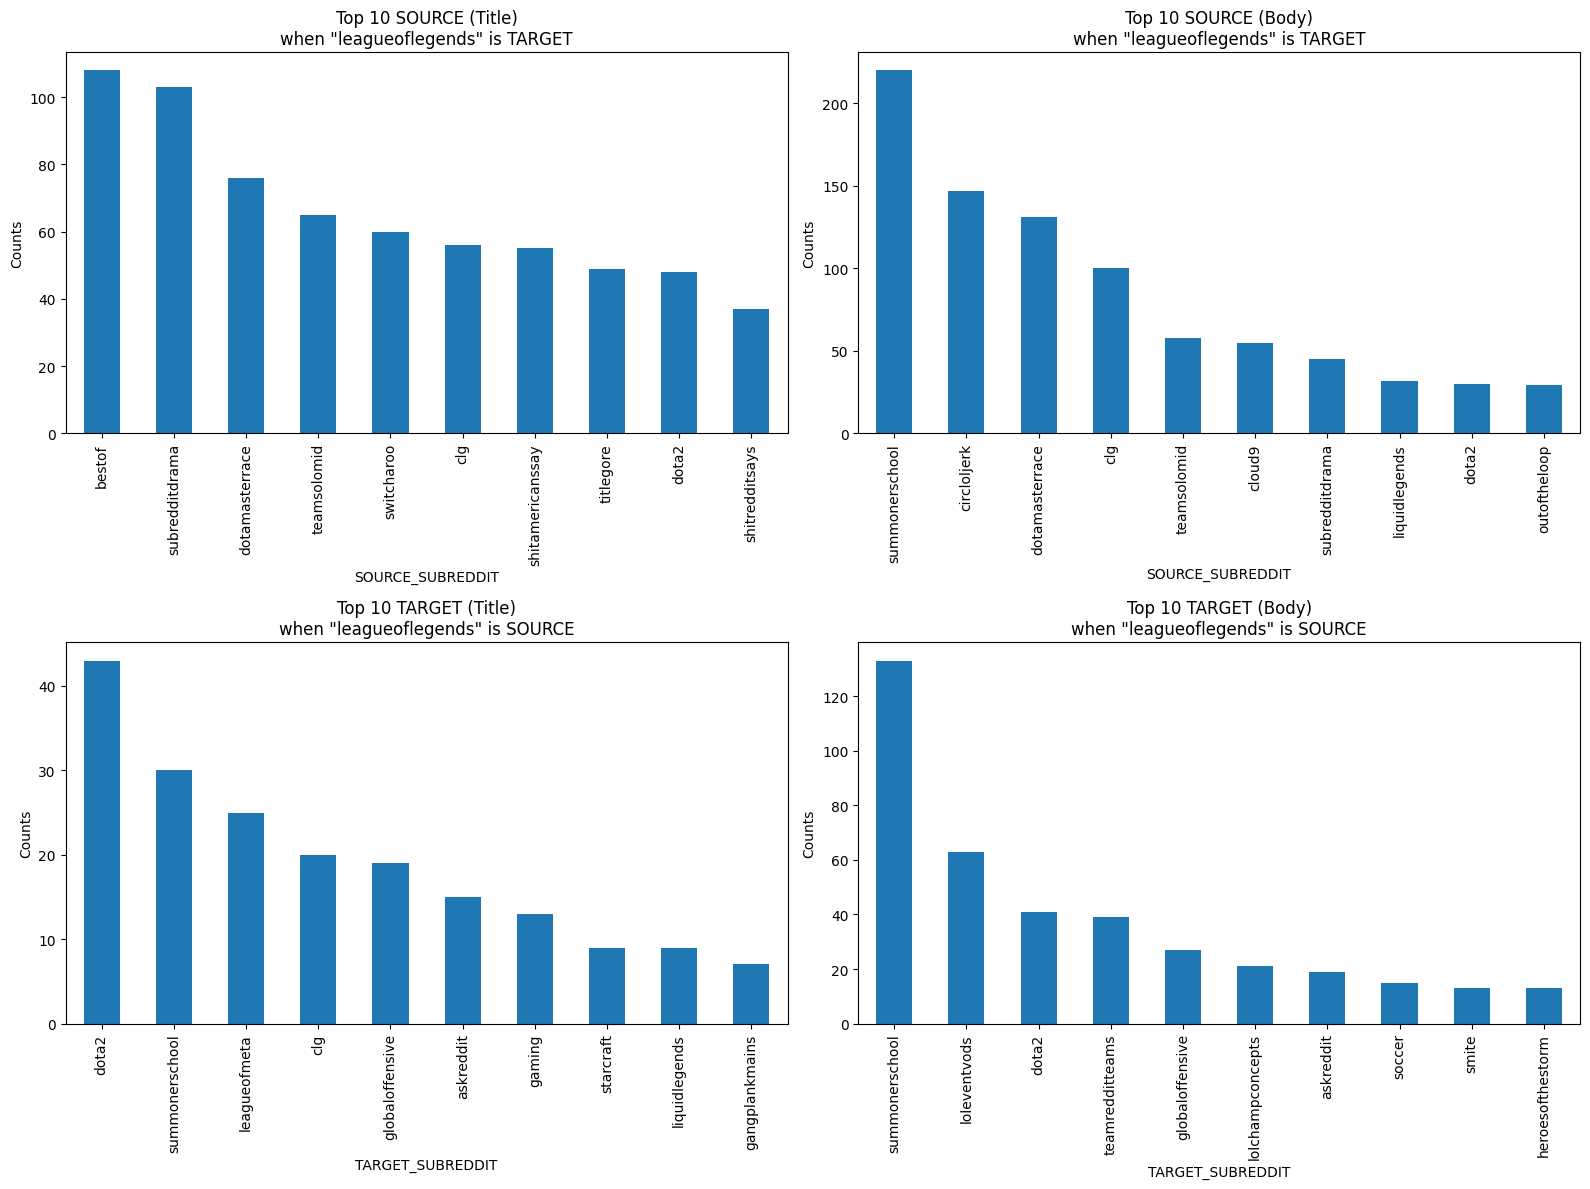

In [4]:
# subreddit = 'dota2'
subreddit = "leagueoflegends"
# subreddit = 'starcraft2'
# subreddit = 'globaloffensive' # globaloffensive or csgo

top_10_source_title = df_title[df_title["TARGET_SUBREDDIT"]==subreddit]["SOURCE_SUBREDDIT"].value_counts().head(10)
top_10_target_title = df_title[df_title["SOURCE_SUBREDDIT"]==subreddit]["TARGET_SUBREDDIT"].value_counts().head(10)

top_10_source_body = df_body[df_body["TARGET_SUBREDDIT"]==subreddit]["SOURCE_SUBREDDIT"].value_counts().head(10)
top_10_target_body = df_body[df_body["SOURCE_SUBREDDIT"]==subreddit]["TARGET_SUBREDDIT"].value_counts().head(10)

plt.figure(figsize=(16, 12))

# 1. Source Title
plt.subplot(2, 2, 1)
top_10_source_title.plot(kind='bar')
plt.title(f'Top 10 SOURCE (Title)\nwhen "{subreddit}" is TARGET')
plt.ylabel('Counts')

# 2. Source Body
plt.subplot(2, 2, 2)
top_10_source_body.plot(kind='bar')
plt.title(f'Top 10 SOURCE (Body)\nwhen "{subreddit}" is TARGET')
plt.ylabel('Counts')

# 3. Target Title
plt.subplot(2, 2, 3)
top_10_target_title.plot(kind='bar')
plt.title(f'Top 10 TARGET (Title)\nwhen "{subreddit}" is SOURCE')
plt.ylabel('Counts')

# 4. Target Body
plt.subplot(2, 2, 4)
top_10_target_body.plot(kind='bar')
plt.title(f'Top 10 TARGET (Body)\nwhen "{subreddit}" is SOURCE')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()


In [5]:
dota2_list = []
string = "dota2"
temp = list(df_body[df_body["SOURCE_SUBREDDIT"].str.contains("dota2", case=False, na=False)].SOURCE_SUBREDDIT.unique())
dota2_list.extend(temp)
temp = list(df_body[df_body["TARGET_SUBREDDIT"].str.contains("dota2", case=False, na=False)].TARGET_SUBREDDIT.unique())
dota2_list.extend(temp)
temp = list(df_title[df_title["SOURCE_SUBREDDIT"].str.contains("dota2", case=False, na=False)].SOURCE_SUBREDDIT.unique())
dota2_list.extend(temp)
temp = list(df_title[df_title["TARGET_SUBREDDIT"].str.contains("dota2", case=False, na=False)].TARGET_SUBREDDIT.unique())
dota2_list.extend(temp)
dota2_list = list(set(dota2_list))
print(f"Total unique subreddits related to 'dota2': {len(dota2_list)}")
# smite_list

Total unique subreddits related to 'dota2': 74


In [6]:
df = df_title
sub = df[df["SOURCE_SUBREDDIT"].isin(dota2_list) | df["TARGET_SUBREDDIT"].isin(dota2_list)]
print(sub["SOURCE_SUBREDDIT"].value_counts().head(10))
print(sub["TARGET_SUBREDDIT"].value_counts().head(10))



SOURCE_SUBREDDIT
dota2              653
dota2circlejerk    195
subredditdrama      91
dotamasterrace      79
bestof              75
learndota2          61
shitredditsays      48
leagueoflegends     45
titlegore           34
circlebroke2        33
Name: count, dtype: int64
TARGET_SUBREDDIT
dota2              1480
leagueoflegends      52
globaloffensive      44
learndota2           36
dota2modding         30
askreddit            29
dotaconcepts         28
truedota2            27
steam                23
dota2circlejerk      18
Name: count, dtype: int64


In [7]:
temp_list = []
string = "offensive"
temp = list(df_body[df_body["SOURCE_SUBREDDIT"].str.contains(string, case=False, na=False)].SOURCE_SUBREDDIT.unique())
temp_list.extend(temp)
temp = list(df_body[df_body["TARGET_SUBREDDIT"].str.contains(string, case=False, na=False)].TARGET_SUBREDDIT.unique())
temp_list.extend(temp)
temp = list(df_title[df_title["SOURCE_SUBREDDIT"].str.contains(string, case=False, na=False)].SOURCE_SUBREDDIT.unique())
temp_list.extend(temp)
temp = list(df_title[df_title["TARGET_SUBREDDIT"].str.contains(string, case=False, na=False)].TARGET_SUBREDDIT.unique())
temp_list.extend(temp)
temp_list = list(set(temp_list))
print(f"Total unique subreddits related to {string}: {len(temp_list)}")

Total unique subreddits related to offensive: 17


In [8]:
temp_list

['globaloffensive',
 'globaloffensivelinux',
 'globaloffensivetest',
 'offensive_wallpapers',
 'offensiveflags',
 'globaloffensivemarket',
 'classicoffensive',
 'globaloffensive_vods',
 'offensivejokes',
 'kyleoffensive',
 'ripglobaloffensive',
 'isitfunnyoroffensive',
 'globaloffensivetrade',
 'globaloffensivetil',
 'offensive',
 'offensivespeech',
 'globaloffensivegamble']

In [12]:
dota2_subreddits = [
    'dota2', 'dota2circlejerk','dota2trade', 'learndota2', 'dota2betting', 
    'dotamasterrace', 'truedota2', 'dota2modding', 'dota2loungebets', 'redditdota2league',
]
lol_subreddits = [
    "leagueoflegends", "leagueoflegendsmeta", "summonerschool",  "clg", 
    "circloljerk", 'leagueconnect', 'lolesports'
    ]

starcraft2_subreddits = [
     'starcraft2',  'starcraft', 'starcraftcirclejerk', 'unexpectedstarcraft',
     'imaginarystarcraft', 'starcraft_strategy', 'ukstarcraft', 'starcraftbirthdays',
     'starcraftdeutschland', 'huskystarcraft', 'starcraftfeedback','psystarcraft',]

globaloffensive_subreddits = [
    'globaloffensive', 'globaloffensivetrade', 'globaloffensivemarket',
    'csgo', 'csgojerk', 'csgobetting',
]

games = ["gaming", "dota2", "leagueoflegends", "starcraft2", "globaloffensive"]


In [13]:
properties_list = [
    # 'LIWC_FUNCT',
#  'LIWC_RELAT',
#  'LIWC_PREP',
#  'LIWC_COG',
#  'LIWC_VERB',
 'LIWC_SOC',
#  'LIWC_PRON',
 'LIWC_AFFECT',
#  'LIWC_SPACE',
#  'LIWC_PRES',
#  'LIWC_ART',
 'LIWC_LEISURE',
#  'LIWC_AUXVB',
#  'LIWC_TIME',
 'LIWC_POSEMO',
#  'LIWC_PPRON',
#  'LIWC_IPRON',
#  'LIWC_ADV',
#  'LIWC_CONJ',
#  'LIWC_INCL',
 'LIWC_NEGEMO',
 'LIWC_ACHIEV',
 'LIWC_INSIGHT',
#  'LIWC_QUANT',
 'LIWC_WORK',
#  'LIWC_CAUSE',
#  'LIWC_EXCL',
#  'LIWC_PAST',
#  'LIWC_TENT',
 'LIWC_BIO'
 'LIWC_PERCEPT',
 ]

for f in top_30:
    print(f, PROPERTIES[f])

NameError: name 'top_30' is not defined

In [14]:
selected_PROPERTIES = {
    # "N_CHARS": "Number of characters", # Total number of characters
    # "N_CHARS_NO_WS": "Number of characters without white space", # Characters excluding whitespace
    # "FRAC_ALPHA": "Fraction alphabetic characters", # Fraction of alphabetic letters
    # "FRAC_DIGIT": "Fraction digits", # Fraction of digits
    # "FRAC_UPPER": "Fraction uppercase characters", # Fraction of uppercase letters
    # "FRAC_WS": "Fraction white space", # Fraction of whitespace characters
    # "FRAC_SPECIAL": "Fraction special characters", # Fraction of punctuation/special chars
    # "N_WORDS": "Number of words", # Total word count
    # "N_UNIQUE_WORDS": "Number of unique words", # Unique word count
    # "N_LONG_WORDS": "Number of long words", # Words with at least 6 characters
    # "AVG_WORD_LEN": "Average word length", # Mean word length
    # "N_UNIQUE_STOP": "Number of unique stopwords", # Unique stopwords count
    # "FRAC_STOP": "Fraction stopwords", # Fraction of tokens that are stopwords
    # "N_SENT": "Number of sentences", # Sentence count
    # "N_LONG_SENT": "Number of long sentences", # Sentences with at least 10 words
    # "AVG_CHAR_SENT": "Average characters per sentence", # Mean characters per sentence
    # "AVG_WORD_SENT": "Average words per sentence", # Mean words per sentence
    # "ARI": "Automated Readability Index", # Readability score
    # "VADER_POS": "VADER Positive", # Positive sentiment score (VADER)
    # "VADER_NEG": "VADER Negative", # Negative sentiment score (VADER)
    # "VADER_COMP": "VADER Compound", # Compound sentiment score (VADER)
    # "LIWC_FUNCT": "LIWC Func. words", # Function words (articles, prepositions, conjunctions)
    # "LIWC_PRON": "LIWC Pronouns", # All pronouns
    # "LIWC_PPRON": "LIWC Pers. pronouns", # Personal pronouns (I, you, he, she, we, they)
    # "LIWC_I": "LIWC I", # First-person singular "I"
    # "LIWC_WE": "LIWC We", # First-person plural "we"
    # "LIWC_YOU": "LIWC You", # Second-person "you"
    # "LIWC_SHEHE": "LIWC SheHe", # Third-person singular (she, he)
    # "LIWC_THEY": "LIWC They", # Third-person plural (they)
    # "LIWC_IPRON": "LIWC Imp. pronouns", # Impersonal/indefinite pronouns (it, one)
    # "LIWC_ART": "LIWC Articles", # Articles (a, an, the)
    # "LIWC_VERB": "LIWC Verbs", # All verb forms
    # "LIWC_AUXVB": "LIWC Aux. verbs", # Auxiliary verbs (be, have, do, modals)
    # "LIWC_PAST": "LIWC Past tense", # Past tense verbs
    # "LIWC_PRES": "LIWC Present tense", # Present tense verbs
    # "LIWC_FUT": "LIWC Future", # Future markers (will, gonna)
    # "LIWC_ADV": "LIWC Adverbs", # Adverbs
    # "LIWC_PREP": "LIWC Prepositions", # Prepositions
    # "LIWC_CONJ": "LIWC Conjunctions", # Conjunctions
    "LIWC_NEG": "LIWC Negation", # Negations (not, no, never)
    "LIWC_QUANT": "LIWC Quantifiers", # Quantifiers (many, few, much)
    "LIWC_NUM": "LIWC Numbers", # Numerals and number words
    "LIWC_SWEAR": "LIWC Swear", # Profanity / swear words
    "LIWC_SOC": "LIWC Social", # Social process words (talk, friend, share)
    "LIWC_FAM": "LIWC Family", # Family-related words
    "LIWC_FRIEND": "LIWC Friends", # Friends / peer-related words
    "LIWC_HUMAN": "LIWC Humans", # References to people / humans
    "LIWC_AFFECT": "LIWC Affect", # Emotion words
    "LIWC_POSEMO": "LIWC Pos. emotion", # Positive emotion words
    "LIWC_NEGEMO": "LIWC Neg. emotion", # Negative emotion words
    "LIWC_ANX": "LIWC Anxiety", # Anxiety-related words (nervous, afraid)
    "LIWC_ANGER": "LIWC Anger", # Anger-related words
    "LIWC_SAD": "LIWC Sadness", # Sadness-related words
    # "LIWC_COG": "LIWC Cogn. processes", # Cognitive process words (think, know)
    "LIWC_INSIGHT": "LIWC Insight", # Insight words (realize, understand)
    # "LIWC_CAUSE": "LIWC Cause", # Causal words (because, therefore)
    # "LIWC_DISCREP": "LIWC Discrepancy", # Discrepancy words (should, would, could)
    # "LIWC_TENT": "LIWC Tentative", # Tentative words (maybe, perhaps)
    "LIWC_CERT": "LIWC Certainty", # Certainty words (definitely, sure)
    "LIWC_INHIB": "LIWC Inhibition", # Inhibition words (stop, prevent, avoid)
    # "LIWC_INCL": "LIWC Inclusion", # Inclusion words (include, with)
    # "LIWC_EXCL": "LIWC Exclusion", # Exclusion words (exclude, without)
    "LIWC_PERCEPT": "LIWC Perceptual", # Perceptual processes (see, hear, feel)
    "LIWC_SEE": "LIWC See", # Vision-related words
    "LIWC_HEAR": "LIWC Hear", # Hearing-related words
    "LIWC_FEEL": "LIWC Feel", # Sensation / feeling words
    "LIWC_BIO": "LIWC Biological", # Biological process words (eat, sleep)
    "LIWC_BODY": "LIWC Body", # Body-part words (arm, head)
    "LIWC_HEALTH": "LIWC Health", # Health-related words
    "LIWC_SEX": "LIWC Sexual", # Sexual content words
    "LIWC_INGEST": "LIWC Ingest", # Eating / drinking words (eat, drink)
    # "LIWC_RELAT": "LIWC Relativity", # Relativity / relational words (near, far)
    "LIWC_MOTION": "LIWC Motion", # Motion verbs (go, move, travel)
    "LIWC_SPACE": "LIWC Space", # Spatial / location words (left, above)
    "LIWC_TIME": "LIWC Time", # Temporal words (when, day, year)
    "LIWC_WORK": "LIWC Work", # Work and occupational words
    "LIWC_ACHIEV": "LIWC Achievement", # Achievement / goal words
    "LIWC_LEISURE": "LIWC Leisure", # Leisure and recreation words
    "LIWC_HOME": "LIWC Home", # Home / domestic words
    "LIWC_MONEY": "LIWC Money", # Money / finance words
    "LIWC_RELIG": "LIWC Religion", # Religion and spirituality words
    "LIWC_DEATH": "LIWC Death", # Death-related words
    "LIWC_ASSENT": "LIWC Assent", # Agreement / approval words (yes, okay)
    "LIWC_DISSENT": "LIWC Dissent", # Disagreement / opposition words (no, oppose)
    "LIWC_NONFLU": "LIWC Nonfluencies", # Non-fluencies (uh, um, repetitions)
    "LIWC_FILLER": "LIWC Filler", # Filler phrases (you know, I mean)
}

### Sentiment andLIWC attributes

,Feature,Mean_Title,Max_Title,Sum_Title,Std_Title,Mean_Body,Max_Body,Sum_Body,Std_Body
4,LIWC_SOC,0.05829,0.67,743.03,0.07387,0.07402,0.32,566.05,0.03529
8,LIWC_AFFECT,0.04502,0.75,573.92,0.06376,0.04141,0.21,316.63,0.02908
29,LIWC_WORK,0.01425,0.43,181.65,0.03617,0.04030,0.33,308.19,0.02564
27,LIWC_SPACE,0.04306,0.40,548.92,0.05885,0.03913,0.25,299.25,0.02744
28,LIWC_TIME,0.03034,0.43,386.72,0.05217,0.03155,0.22,241.24,0.02556
9,LIWC_POSEMO,0.02838,0.40,361.72,0.05041,0.02952,0.14,225.74,0.02403
21,LIWC_BIO,0.01165,0.52,148.47,0.03629,0.02354,0.18,180.04,0.02292
1,LIWC_QUANT,0.01434,0.33,182.79,0.03372,0.02151,0.18,164.46,0.01866
31,LIWC_LEISURE,0.03450,0.50,439.80,0.05618,0.02069,0.17,158.25,0.02224
22,LIWC_BODY,0.00466,0.52,59.39,0.02304,0.01931,0.12,147.67,0.02209


['LIWC_SOC', 'LIWC_AFFECT', 'LIWC_WORK', 'LIWC_SPACE', 'LIWC_TIME', 'LIWC_POSEMO', 'LIWC_BIO', 'LIWC_QUANT', 'LIWC_LEISURE', 'LIWC_BODY']


<Axes: title={'center': 'LIWC Properties Heatmap (Body) (Normalized)'}>

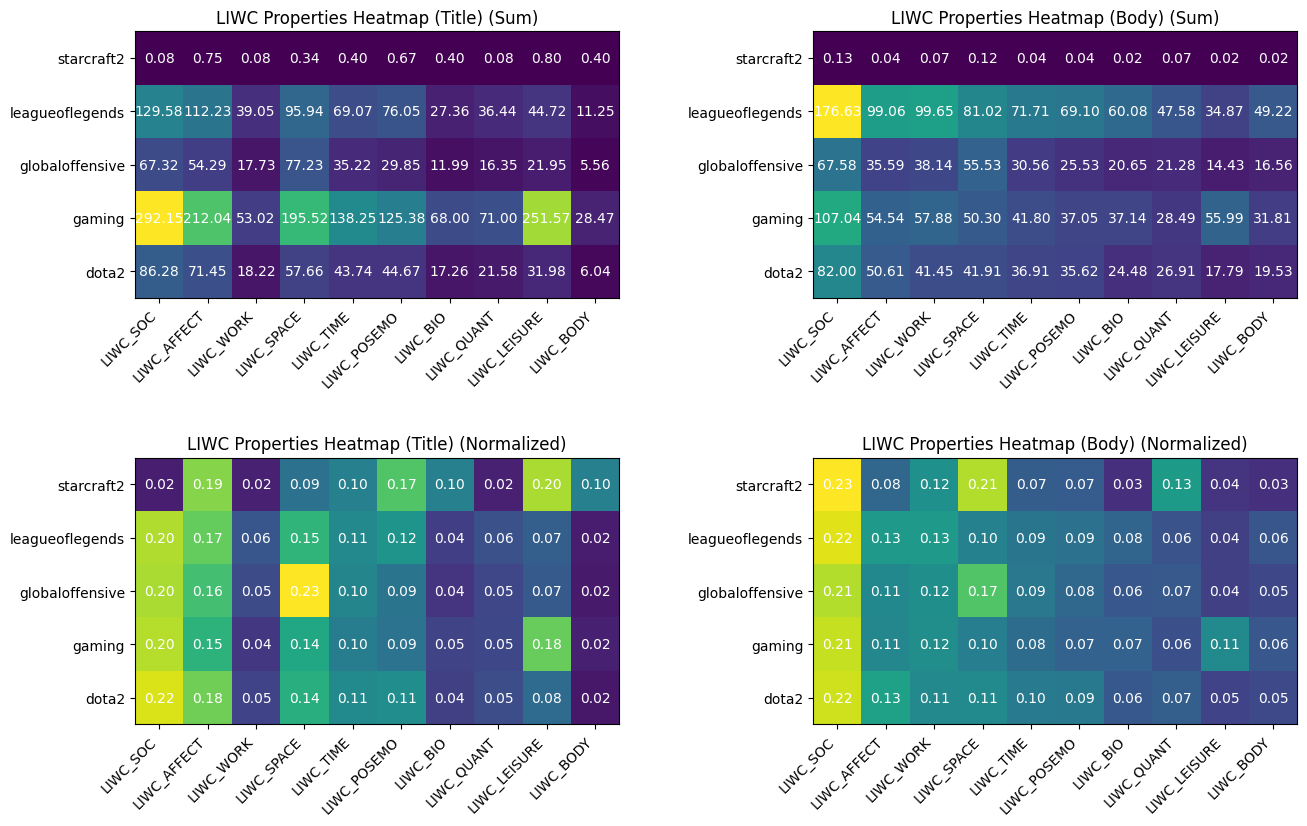

In [25]:
from week1_Yuri import plot_liwc_heatmaps_for_features_list
from src.consts import PROPERTIES
from week1_Yuri import get_dataframe_features

subreddits_list = games
df_features = get_dataframe_features(
    df_title, df_body, selected_PROPERTIES.keys(), subreddits_list
)
display(df_features.sort_values(
    by=['Sum_Body', 'Sum_Title',], ascending=False
).head(10))

# VADER sentiment
# properties_list = [ "VADER_POS", "VADER_NEG", "VADER_COMP",]

# LIWC properties
properties_list = df_features.sort_values(
    by=['Sum_Body', 'Sum_Title',], ascending=False
).head(10)["Feature"].tolist()
print(properties_list)
fig, ax = plt.subplots(2, 2, figsize = (15, 9))
plt.subplots_adjust(hspace=0.6, wspace=0.4)
plot_liwc_heatmaps_for_features_list(
    ax[0, 0], df_title, games, properties_list, title='LIWC Properties Heatmap (Title)')

plot_liwc_heatmaps_for_features_list(
    ax[0, 1], df_body, games, properties_list, title='LIWC Properties Heatmap (Body)')

plot_liwc_heatmaps_for_features_list(
    ax[1, 0], df_title, games, properties_list, title='LIWC Properties Heatmap (Title)', normalize=True)

plot_liwc_heatmaps_for_features_list(
    ax[1, 1], df_body, games, properties_list, title='LIWC Properties Heatmap (Body)', normalize=True)

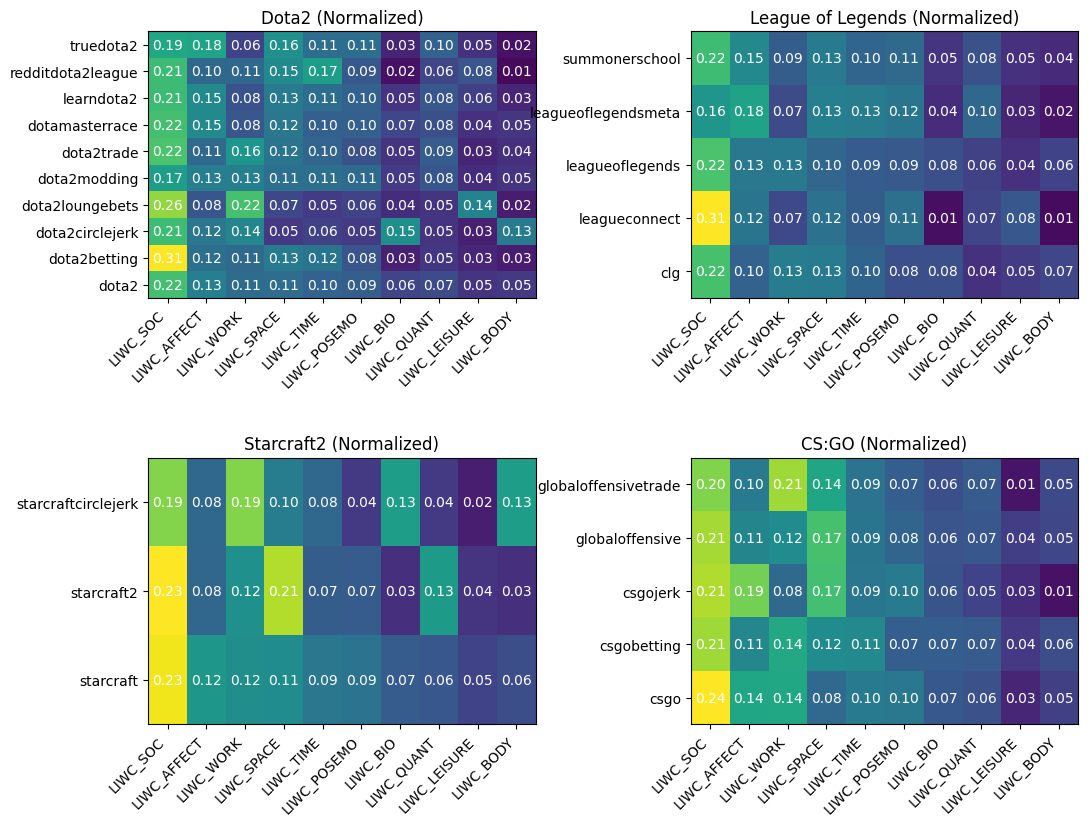

In [21]:
from week1_Yuri import plot_liwc_heatmaps_for_features_list

fig, ax = plt.subplots(2, 2, figsize = (12, 9))
plt.subplots_adjust(hspace=0.6, wspace=0.4)
# properties_list = df_features_liwc.sort_values(by=['Sum_Title', 'Sum_Body'], ascending=False).head(10)["Feature"].tolist()
plot_liwc_heatmaps_for_features_list(
    ax[0][0], df_body, dota2_subreddits, properties_list, title='Dota2',normalize=True)
plot_liwc_heatmaps_for_features_list(
    ax[0][1], df_body, lol_subreddits, properties_list, title='League of Legends', normalize=True)
plot_liwc_heatmaps_for_features_list(
    ax[1][0], df_body, starcraft2_subreddits, properties_list, title='Starcraft2', normalize=True)
plot_liwc_heatmaps_for_features_list(
    ax[1][1], df_body, globaloffensive_subreddits, properties_list, title='CS:GO'  , normalize=True)

### Spikes and trends of selected features over time for a given subreddits

Title
3338


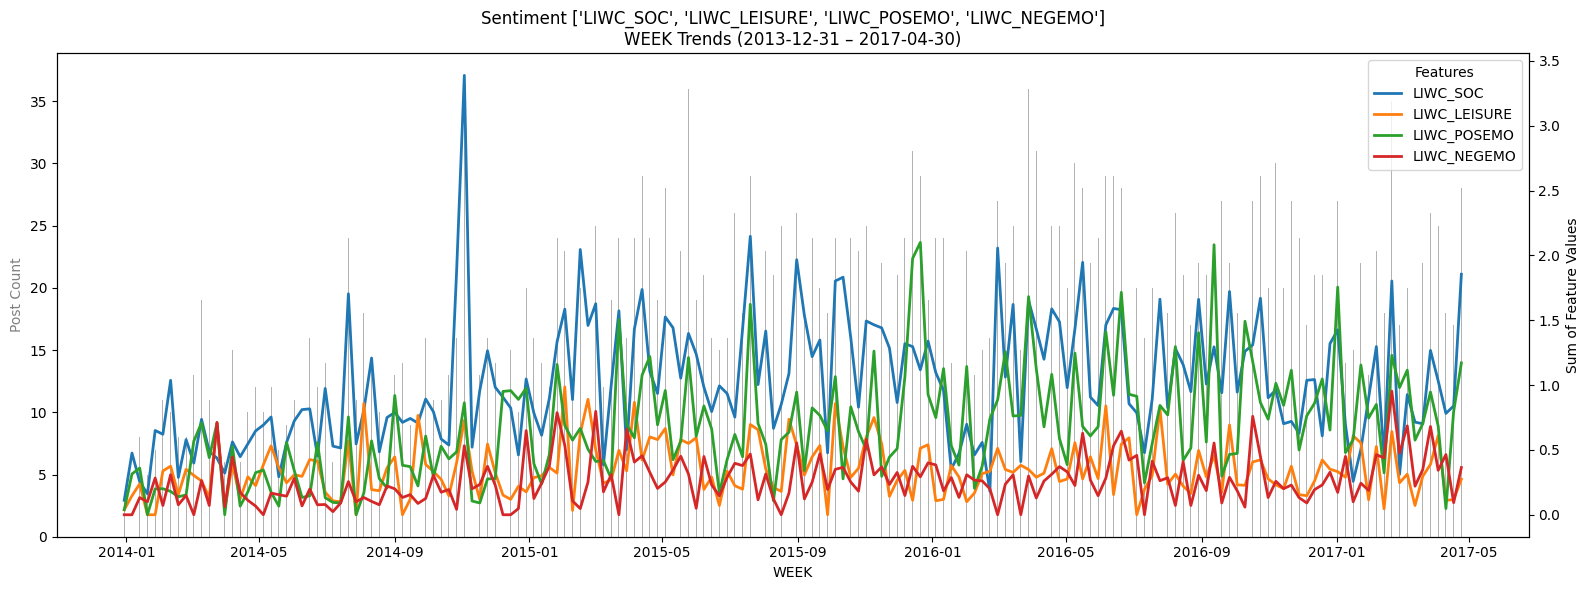

Body
3609


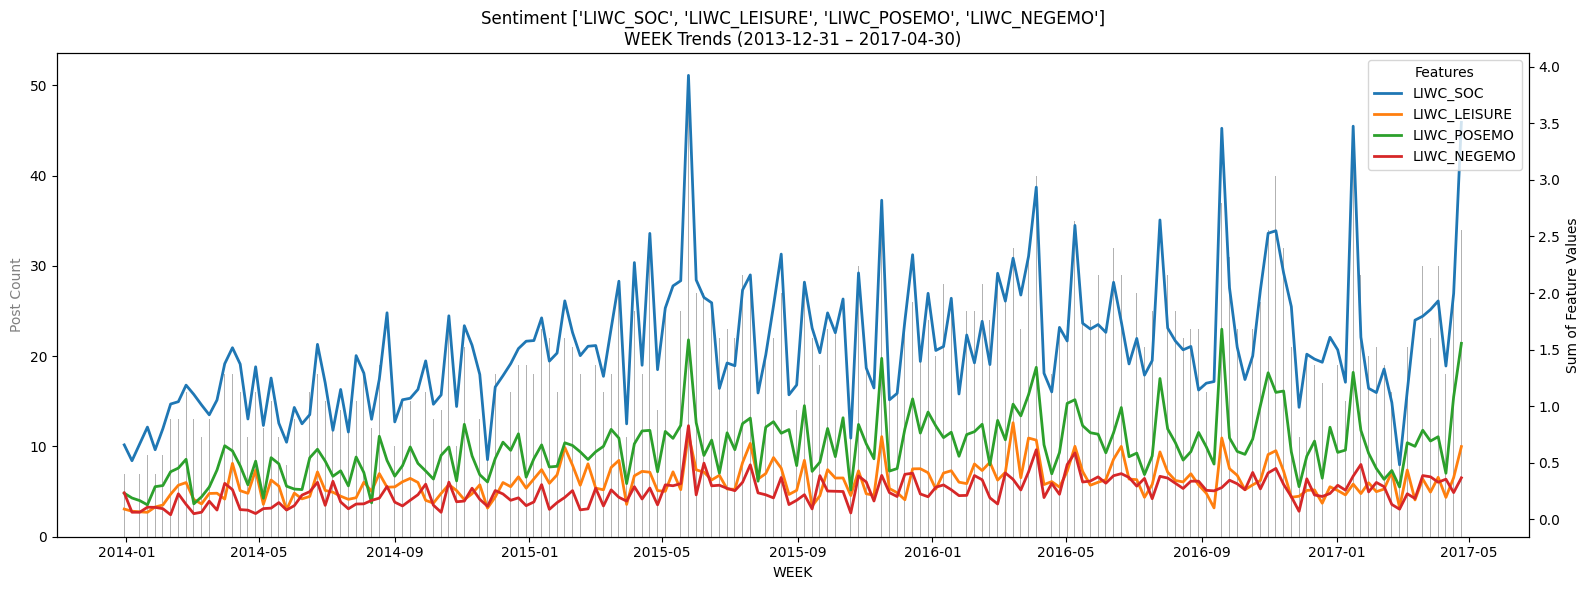

In [23]:
from week1_Yuri import plot_subreddits_features_trend 
subreddits_list = lol_subreddits
start_time = "2013-12-31"
end_time = "2017-04-30"
features_list = [
    "LIWC_SOC",
    "LIWC_LEISURE",
    "LIWC_POSEMO",
    "LIWC_NEGEMO",
]
period = "W"  # "D" for daily, "W" for weekly, "M" for monthly, "Q" for quarterly, "Y" for yearly
print("Title")
plot_subreddits_features_trend(df_title, subreddits_list, start_time, end_time, features_list, period)
print("Body")
plot_subreddits_features_trend(df_body, subreddits_list, start_time, end_time, features_list, period)